### Ali Abdullah Ahmad
## CWID- 20031246
## Using 1 late day out of the 2 remaining late days

1. Data preparation (10 points)
    1) (5 points) Data download and preprocessing:

In [1]:
from datasets import load_dataset
ds = load_dataset("squad_v2")

In [2]:
answerable = [x for x in ds["train"] if len(x["answers"]["text"]) > 0]

In [3]:
import random
random.seed(42)

samples = random.sample(answerable, 15)


In [4]:
formatted = []
for item in samples:
    formatted.append({
        "context": item["context"],
        "question": item["question"],
        "answer": item["answers"]["text"][0],
    })


In [5]:
formatted


[{'context': 'The governors of the taifas each proclaimed themselves Emir of their provinces and established diplomatic relations with the Christian kingdoms of the north. Most of Portugal fell into the hands of the Taifa of Badajoz of the Aftasid Dynasty, and after a short spell of an ephemeral Taifa of Lisbon in 1022, fell under the dominion of the Taifa of Seville of the Abbadids poets. The Taifa period ended with the conquest of the Almoravids who came from Morocco in 1086 winning a decisive victory at the Battle of Sagrajas, followed a century later in 1147, after the second period of Taifa, by the Almohads, also from Marrakesh.',
  'question': 'Which which kingdoms did the taifas establish diplomatic relations?',
  'answer': 'the Christian kingdoms of the north'},
 {'context': 'Nanjing first became a state capital in 229 AD, when the state of Eastern Wu founded by Sun Quan during the Three Kingdoms period relocated its capital to Jianye (建業), the city extended on the basis of Jin

2) (5 points) Data statistics: 

,min,max,avg
context,34,168,100.87
question,4,14,9.93
answer,1,9,3.33


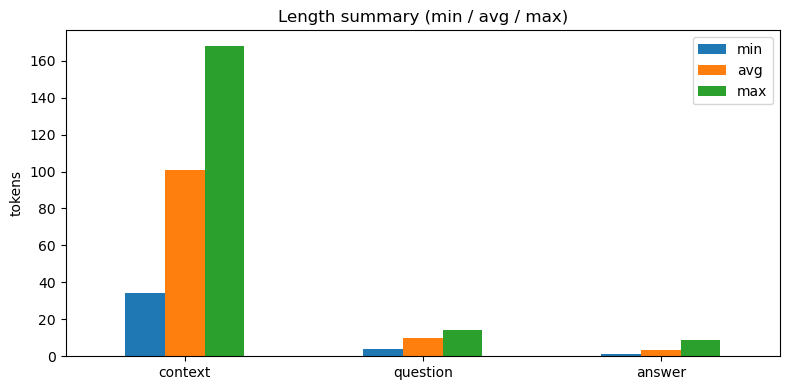

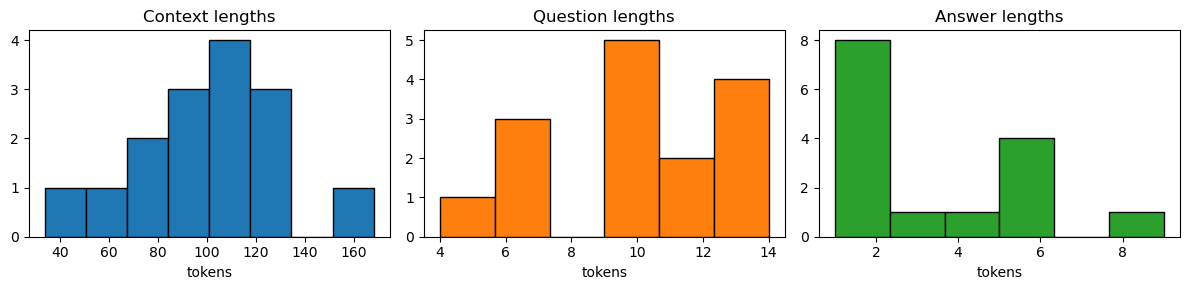

In [6]:
import numpy as np
import pandas as pd
from IPython.display import display
import matplotlib.pyplot as plt

# Extract lengths
context_lens = [len(x["context"].split()) for x in formatted]
question_lens = [len(x["question"].split()) for x in formatted]
answer_lens = [len(x["answer"].split()) for x in formatted]

def stats(arr):
    return {
        "min": int(np.min(arr)),
        "max": int(np.max(arr)),
        "avg": float(np.mean(arr))
    }

context_stats = stats(context_lens)
question_stats = stats(question_lens)
answer_stats = stats(answer_lens)



# summary table
stats_df = pd.DataFrame([context_stats, question_stats, answer_stats],
                        index=['context','question','answer'])
display(stats_df.style.format({'min': '{:.0f}', 'max': '{:.0f}', 'avg': '{:.2f}'}))

# bar chart for min/avg/max
ax = stats_df[['min','avg','max']].plot(kind='bar', figsize=(8,4), rot=0)
ax.set_ylabel('tokens')
ax.set_title('Length summary (min / avg / max)')
plt.tight_layout()

# distribution histograms
fig, axes = plt.subplots(1, 3, figsize=(12,3))
axes[0].hist(context_lens, bins=8, color='C0', edgecolor='k'); axes[0].set_title('Context lengths'); axes[0].set_xlabel('tokens')
axes[1].hist(question_lens, bins=6, color='C1', edgecolor='k'); axes[1].set_title('Question lengths'); axes[1].set_xlabel('tokens')
axes[2].hist(answer_lens, bins=6, color='C2', edgecolor='k'); axes[2].set_title('Answer lengths'); axes[2].set_xlabel('tokens')
plt.tight_layout()
plt.show()


In [ ]:
# Part 2: RoBERTa QA 
# Outputs per sample:
#  - start_token_index, end_token_index (indices in the tokenized input)
#  - predicted_token_ids (vocab indices for the predicted span)
#  - decoded_answer (text span)

from transformers import AutoTokenizer, AutoModelForQuestionAnswering
import torch
import numpy as np

MODEL_NAME = "deepset/roberta-base-squad2"  # pretrained RoBERTa SQuAD2 checkpoint
MAX_LENGTH = 512           # max tokens for tokenizer
MAX_ANSWER_TOKENS = 30     # limit for candidate span length when searching end >= start

device = "cuda" if torch.cuda.is_available() else "cpu"

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME, use_fast=True)
model = AutoModelForQuestionAnswering.from_pretrained(MODEL_NAME).to(device)
model.eval()

def predict_best_span(question: str, context: str):
    # Tokenize with offsets to map tokens -> char spans
    inputs = tokenizer(
        question,
        context,
        truncation="only_second",
        max_length=MAX_LENGTH,
        return_offsets_mapping=True,
        return_tensors="pt",
    ).to(device)

    # Keep a CPU copy of offset mapping for char-level mapping
    offset_mapping = inputs.pop("offset_mapping")[0].cpu().tolist()
    input_ids = inputs["input_ids"][0].cpu().tolist()

    with torch.no_grad():
        outputs = model(**inputs)
    start_logits = outputs.start_logits[0].cpu().numpy()
    end_logits = outputs.end_logits[0].cpu().numpy()

    # Constrained search: choose (s,e) with e >= s, e-s+1 <= MAX_ANSWER_TOKENS, maximize start+end logits
    best_score = -1e9
    best_s, best_e = 0, 0
    L = len(start_logits)
    for s in range(L):
        # allow question tokens too,
        # because indices requested are in the tokenized input. Offsets of (0,0) indicate special/question tokens.
        # We'll still enforce e>=s and a small max length.
        max_e = min(L - 1, s + MAX_ANSWER_TOKENS - 1)
        for e in range(s, max_e + 1):
            score = start_logits[s] + end_logits[e]
            if score > best_score and e >= s:
                best_score = score
                best_s, best_e = s, e

    # Extract predicted token ids (vocab indices) and decoded text
    pred_token_ids = input_ids[best_s : best_e + 1]
    decoded = tokenizer.decode(pred_token_ids, clean_up_tokenization_spaces=True, skip_special_tokens=True)

    # Map token indices to character indices in the original context (if offsets available)
    # offset_mapping entries are tuples; for question/special tokens offsets can be (0,0)
    # We return char_start/char_end only if offsets for selected tokens are non-(0,0)
    char_start, char_end = None, None
    # find first non-(0,0) offset from best_s..best_e
    for idx in range(best_s, best_e + 1):
        off = offset_mapping[idx]
        if off != (0, 0):
            char_start = off[0]
            break
    # find last non-(0,0) offset
    for idx in range(best_e, best_s - 1, -1):
        off = offset_mapping[idx]
        if off != (0, 0):
            char_end = off[1]
            break

    return {
        "start_token_index": int(best_s),
        "end_token_index": int(best_e),
        "predicted_token_ids": pred_token_ids,
        "decoded_answer": decoded,
        "char_start_in_context": char_start,
        "char_end_in_context": char_end,
        "input_ids": input_ids,                # full tokenized input ids (for inspection)
        "token_slice_tokens": tokenizer.convert_ids_to_tokens(input_ids[max(0, best_s-8):min(len(input_ids), best_e+9)])
    }

# Run predictions for each sample in `formatted` and print only the required outputs
for i, sample in enumerate(formatted, start=1):
    q = sample["question"]
    c = sample["context"]
    pred = predict_best_span(q, c)

    print(f"=== Sample {i} ===")
    print("Question:", q)
    # Required outputs:
    print("Start token index (in tokenized input):", pred["start_token_index"])
    print("End token index   (in tokenized input):", pred["end_token_index"])
    print("Predicted answer token ids (vocab indices):", pred["predicted_token_ids"])
    print("Decoded answer (predicted text):", repr(pred["decoded_answer"]))

    print("Char start in context (if available):", pred["char_start_in_context"])
    print("Char end   in context (if available):", pred["char_end_in_context"])
    #small token context around the predicted span (tokens)
    print("Token slice around prediction (tokens):", pred["token_slice_tokens"])
    print("-------------------------------\n")


=== Sample 1 ===
Question: Which which kingdoms did the taifas establish diplomatic relations?
Start token index (in tokenized input): 35
End token index   (in tokenized input): 39
Predicted answer token ids (vocab indices): [2412, 45658, 9, 5, 1926]
Decoded answer (predicted text): ' Christian kingdoms of the north'
Char start in context (if available): 125
Char end   in context (if available): 156
Token slice around prediction (tokens): ['Ġtheir', 'Ġprovinces', 'Ġand', 'Ġestablished', 'Ġdiplomatic', 'Ġrelations', 'Ġwith', 'Ġthe', 'ĠChristian', 'Ġkingdoms', 'Ġof', 'Ġthe', 'Ġnorth', '.', 'ĠMost', 'Ġof', 'ĠPortugal', 'Ġfell', 'Ġinto', 'Ġthe', 'Ġhands']
-------------------------------

=== Sample 2 ===
Question: When was Nanjing extended?
Start token index (in tokenized input): 61
End token index   (in tokenized input): 62
Predicted answer token ids (vocab indices): [26763, 4516]
Decoded answer (predicted text): ' 211 AD'
Char start in context (if available): 216
Char end   in context (i

In [9]:
context = [s["context"] for s in formatted]
context

['The governors of the taifas each proclaimed themselves Emir of their provinces and established diplomatic relations with the Christian kingdoms of the north. Most of Portugal fell into the hands of the Taifa of Badajoz of the Aftasid Dynasty, and after a short spell of an ephemeral Taifa of Lisbon in 1022, fell under the dominion of the Taifa of Seville of the Abbadids poets. The Taifa period ended with the conquest of the Almoravids who came from Morocco in 1086 winning a decisive victory at the Battle of Sagrajas, followed a century later in 1147, after the second period of Taifa, by the Almohads, also from Marrakesh.',
 'Nanjing first became a state capital in 229 AD, when the state of Eastern Wu founded by Sun Quan during the Three Kingdoms period relocated its capital to Jianye (建業), the city extended on the basis of Jinling Yi in 211 AD. Although conquered by the Western Jin dynasty in 280, Nanjing and its neighbouring areas had been well cultivated and developed into one of th

In [10]:
questions = [s["question"] for s in formatted]
questions

['Which which kingdoms did the taifas establish diplomatic relations?',
 'When was Nanjing extended?',
 'In what district of Manhattan were the Occupy Wall Street protests?',
 'Illyrian pirates caused two wars in the Balkans with what Empire?',
 'How many people were killed in the largest mass execution in US history?',
 'A mobile weapons system is likely to pop up where?',
 'Who had abbeys in the Savor and one in the center of Interlaken?',
 'What are the names of the two separate Estonian languages?',
 "What caused Latin America's right-wing authorities to support coup o'etats?",
 'What hemisphere of stars did Edmond Halley want to study with the telescope?',
 'When did approach lighting come into use?',
 'Why was the Greater London Council established?',
 'In what year did Frank Shuman patent his solar engine?',
 'Who gathered impressions of To Kill a Mockingbird from other authors and famous people?',
 'What frequency bands does Compass-M1 transmit in?']

## 2) CHATGPT

You are performing a question answering evaluation.
Follow these rules strictly:

Read the given context paragraph.

Read the question that must be answered using ONLY the information found in the context.

Provide:

A Short and Final Answer

Do NOT invent facts not present in the context.
Do NOT output anything except the Answer and Explanation.

### 1
Context: 'context': 'Nanjing first became a state capital in 229 AD, when the state of Eastern Wu founded by Sun Quan during the Three Kingdoms period relocated its capital to Jianye (建業), the city extended on the basis of Jinling Yi in 211 AD. Although conquered by the Western Jin dynasty in 280, Nanjing and its neighbouring areas had been well cultivated and developed into one of the commercial, cultural and political centers of China during the rule of East Wu. This city would soon play a vital role in the following centuries.', 

Question: 'question': 'When was Nanjing extended?'

ChatGPT said:

Answer: 211 AD

Explanation: The context states that the city "extended on the basis of Jinling Yi in 211 AD," directly giving the year it was extended.

### 2
context : 'The governors of the taifas each proclaimed themselves Emir of their provinces and established diplomatic relations with the Christian kingdoms of the north. Most of Portugal fell into the hands of the Taifa of Badajoz of the Aftasid Dynasty, and after a short spell of an ephemeral Taifa of Lisbon in 1022, fell under the dominion of the Taifa of Seville of the Abbadids poets. The Taifa period ended with the conquest of the Almoravids who came from Morocco in 1086 winning a decisive victory at the Battle of Sagrajas, followed a century later in 1147, after the second period of Taifa, by the Almohads, also from Marrakesh.',

questions : 'Which which kingdoms did the taifas establish diplomatic relations?',

ChatGPT said:

Answer: The Christian kingdoms of the north

Explanation: The context states that the governors of the taifas "established diplomatic relations with the Christian kingdoms of the north," which directly answers the question.

### 3
'The Occupy Wall Street protests in Zuccotti Park in the Financial District of Lower Manhattan began on September 17, 2011, receiving global attention and spawning the Occupy movement against social and economic inequality worldwide.',

 'In what district of Manhattan were the Occupy Wall Street protests?',


ChatGPT said:

Answer: The Financial District of Lower Manhattan

Explanation: The context states that the protests "in Zuccotti Park in the Financial District of Lower Manhattan" began there, directly identifying the district.

### 4
context:'Roman entanglement in the Balkans began when Illyrian piratical raids on Roman merchants led to invasions of Illyria (the First and, Second Illyrian Wars). Tension between Macedon and Rome increased when the young king of Macedon, Philip V harbored one of the chief pirates, Demetrius of Pharos (a former client of Rome). As a result, in an attempt to reduce Roman influence in the Balkans, Philip allied himself with Carthage after Hannibal had dealt the Romans a massive defeat at the Battle of Cannae (216 BC) during the Second Punic War. Forcing the Romans to fight on another front when they were at a nadir of manpower gained Philip the lasting enmity of the Romans; the only real result from the somewhat insubstantial First Macedonian War (215–202 BC).',
  
 
question: 'Illyrian pirates caused two wars in the Balkans with what Empire?',

ChatGPT said:

Answer: Rome

Explanation: The context states that Illyrian piratical raids on Roman merchants led to Roman invasions of Illyria, beginning the First and Second Illyrian Wars.

### 5
context  'The largest single execution in United States history was the hanging of 38 American Indians convicted of murder and rape during the Dakota War of 1862. They were executed simultaneously on December 26, 1862, in Mankato, Minnesota. A single blow from an axe cut the rope that held the large four-sided platform, and the prisoners (except for one whose rope had broken and who had to be re-hanged) fell to their deaths. The second-largest mass execution was also a hanging: the execution of 13 African-American soldiers for taking part in the Houston Riot of 1917. The largest non-military mass execution occurred in one of the original thirteen colonies in 1723, when 26 convicted pirates were hanged in Newport, Rhode Island by order of the Admiralty Court.',
 
question:  'How many people were killed in the largest mass execution in US history?',

ChatGPT said:

Answer: 38

Explanation: The context states that the largest single execution in United States history was the hanging of 38 American Indians during the Dakota War of 1862

### 6 
conetxt:  'Most modern air defence systems are fairly mobile. Even the larger systems tend to be mounted on trailers and are designed to be fairly quickly broken down or set up. In the past, this was not always the case. Early missile systems were cumbersome and required much infrastructure; many could not be moved at all. With the diversification of air defence there has been much more emphasis on mobility. Most modern systems are usually either self-propelled (i.e. guns or missiles are mounted on a truck or tracked chassis) or easily towed. Even systems that consist of many components (transporter/erector/launchers, radars, command posts etc.) benefit from being mounted on a fleet of vehicles. In general, a fixed system can be identified, attacked and destroyed whereas a mobile system can show up in places where it is not expected. Soviet systems especially concentrate on mobility, after the lessons learnt in the Vietnam war between the USA and Vietnam. For more information on this part of the conflict, see SA-2 Guideline.',
 question: 'A mobile weapons system is likely to pop up where?', 

ChatGPT said:

Answer: In places where it is not expected

Explanation: The context states that “a mobile system can show up in places where it is not expected,” describing where such systems are likely to appear.

### 7
context:  'In the 19th century, the monasteries built in the high Alps during the medieval period to shelter travelers and as places of pilgrimage, became tourist destinations. The Benedictines had built monasteries in Lucerne, Switzerland, and Oberammergau; the Cistercians in the Tyrol and at Lake Constance; and the Augustinians had abbeys in the Savoy and one in the center of Interlaken, Switzerland. The Great St Bernard Hospice, built in the 9th or 10th centuries, at the summit of the Great Saint Bernard Pass was shelter for travelers and place for pilgrims since its inception; by the 19th century it became a tourist attraction with notable visitors such as author Charles Dickens and mountaineer Edward Whymper.',
question  'Who had abbeys in the Savor and one in the center of Interlaken?',

ChatGPT said:

Answer: The Augustinians

Explanation: The context states that “the Augustinians had abbeys in the Savoy and one in the center of Interlaken, Switzerland,” directly answering the question

### 8 
context: "The two different historical Estonian languages (sometimes considered dialects), the North and South Estonian languages, are based on the ancestors of modern Estonians' migration into the territory of Estonia in at least two different waves, both groups speaking considerably different Finnic vernaculars. Modern standard Estonian has evolved on the basis of the dialects of Northern Estonia.",

question:  'What are the names of the two separate Estonian languages?', 

ChatGPT said:

Answer: North Estonian and South Estonian

Explanation: The context states that “the two different historical Estonian languages… [are] the North and South Estonian languages,” which directly answers the question.

### 9
context:  "In Latin America in the 1970s, leftists acquired a significant political influence which prompted the right-wing, ecclesiastical authorities and a large portion of the individual country's upper class to support coup d'états to avoid what they perceived as a communist threat. This was further fueled by Cuban and United States intervention which led to a political polarization. Most South American countries were in some periods ruled by military dictatorships that were supported by the United States of America. In the 1970s, the regimes of the Southern Cone collaborated in Operation Condor killing many leftist dissidents, including some urban guerrillas. However, by the early 1990s all countries had restored their democracies.",
question:  "What caused Latin America's right-wing authorities to support coup o'etats?",

ChatGPT said:

Answer: The perceived communist threat from leftists gaining political influence

Explanation: The context states that leftists acquired significant political influence, which prompted right-wing authorities to support coup d’états "to avoid what they perceived as a communist threat," directly explaining their motivation

### 10
context:  "On leaving the University of Oxford, in 1676, Edmond Halley visited Saint Helena and set up an astronomical observatory with a 7.3-metre-long (24 ft) aerial telescope with the intention of studying stars from the Southern Hemisphere. The site of this telescope is near Saint Mathew's Church in Hutt's Gate, in the Longwood district. The 680-metre (2,230 ft) high hill there is named for him and is called Halley's Mount.",

question:  'What hemisphere of stars did Edmond Halley want to study with the telescope?', 

ChatGPT said:

Answer: The Southern Hemisphere

Explanation: The context states that Halley set up the telescope "with the intention of studying stars from the Southern Hemisphere," directly answering the question

### 11
 "The first lighting used on an airport was during the latter part of the 1920s; in the 1930s approach lighting came into use. These indicated the proper direction and angle of descent. The colours and flash intervals of these lights became standardized under the International Civil Aviation Organization (ICAO). In the 1940s, the slope-line approach system was introduced. This consisted of two rows of lights that formed a funnel indicating an aircraft's position on the glideslope. Additional lights indicated incorrect altitude and direction.",

question :  'When did approach lighting come into use?',
 
ChatGPT said:

Answer: In the 1930s

Explanation: The context states that "in the 1930s approach lighting came into use," directly providing the time period.

### 12 
context :  "Primarily starting in the mid-1960s, London became a centre for the worldwide youth culture, exemplified by the Swinging London subculture associated with the King's Road, Chelsea and Carnaby Street. The role of trendsetter was revived during the punk era. In 1965 London's political boundaries were expanded to take into account the growth of the urban area and a new Greater London Council was created. During The Troubles in Northern Ireland, London was subjected to bombing attacks by the Provisional IRA. Racial inequality was highlighted by the 1981 Brixton riot.",

question:  'Why was the Greater London Council established?', 

ChatGPT said:

Answer: To take into account the growth of the urban area

Explanation: The context states that in 1965 "London's political boundaries were expanded… and a new Greater London Council was created," directly linking the council's establishment to the urban area's growth.

### 13 
 'In 1897, Frank Shuman, a U.S. inventor, engineer and solar energy pioneer built a small demonstration solar engine that worked by reflecting solar energy onto square boxes filled with ether, which has a lower boiling point than water, and were fitted internally with black pipes which in turn powered a steam engine. In 1908 Shuman formed the Sun Power Company with the intent of building larger solar power plants. He, along with his technical advisor A.S.E. Ackermann and British physicist Sir Charles Vernon Boys, developed an improved system using mirrors to reflect solar energy upon collector boxes, increasing heating capacity to the extent that water could now be used instead of ether. Shuman then constructed a full-scale steam engine powered by low-pressure water, enabling him to patent the entire solar engine system by 1912.',

question :  'In what year did Frank Shuman patent his solar engine?',

ChatGPT said:

Answer: 1912

Explanation: The context states that Shuman "constructed a full-scale steam engine… enabling him to patent the entire solar engine system by 1912," directly providing the year of the patent.

### 14
 'Reaction to the novel varied widely upon publication. Literary analysis of it is sparse, considering the number of copies sold and its widespread use in education. Author Mary McDonough Murphy, who collected individual impressions of To Kill a Mockingbird by several authors and public figures, calls the book, "an astonishing phenomenon". In 2006, British librarians ranked the book ahead of the Bible as one "every adult should read before they die". It was adapted into an Oscar-winning film in 1962 by director Robert Mulligan, with a screenplay by Horton Foote. Since 1990, a play based on the novel has been performed annually in Harper Lee\'s hometown of Monroeville, Alabama.',

question:  'Who gathered impressions of To Kill a Mockingbird from other authors and famous people?',
ChatGPT said:

Answer: Mary McDonough Murphy

Explanation: The context states that "Author Mary McDonough Murphy… collected individual impressions of To Kill a Mockingbird by several authors and public figures," directly answering the question.

### 15
context: 'Compass-M1 transmits in 3 bands: E2, E5B, and E6. In each frequency band two coherent sub-signals have been detected with a phase shift of 90 degrees (in quadrature). These signal components are further referred to as "I" and "Q". The "I" components have shorter codes and are likely to be intended for the open service. The "Q" components have much longer codes, are more interference resistive, and are probably intended for the restricted service. IQ modulation has been the method in both wired and wireless digital modulation since morsetting carrier signal 100 years ago.']
 question:
 'What frequency bands does Compass-M1 transmit in?']
ChatGPT said:

Answer: E2, E5B, and E6

Explanation: The context states that "Compass-M1 transmits in 3 bands: E2, E5B, and E6," directly listing the frequency bands.

## 3 Claude4.5

### Prompt
You are performing a question answering evaluation.
Follow these rules strictly:
Read the given context paragraph.
Read the question that must be answered using ONLY the information found in the context.
Provide:
A Short and Final Answer
Do NOT invent facts not present in the context.
Do NOT output anything except the Answer and Explanation.
i will give 15 context and 15 question in order answer them in the same order

contexts: [list of context pasted ]

question:[list of questions pasted]

**Answer 1:** The Christian kingdoms of the north

**Explanation:** The context states "The governors of the taifas each proclaimed themselves Emir of their provinces and established diplomatic relations with the Christian kingdoms of the north."

---

**Answer 2:** 211 AD

**Explanation:** The context states "the city extended on the basis of Jinling Yi in 211 AD."

---

**Answer 3:** Financial District of Lower Manhattan

**Explanation:** The context states "The Occupy Wall Street protests in Zuccotti Park in the Financial District of Lower Manhattan began on September 17, 2011."

---

**Answer 4:** Roman Empire (Rome)

**Explanation:** The context states "Roman entanglement in the Balkans began when Illyrian piratical raids on Roman merchants led to invasions of Illyria (the First and, Second Illyrian Wars)."

---

**Answer 5:** 38

**Explanation:** The context states "The largest single execution in United States history was the hanging of 38 American Indians convicted of murder and rape during the Dakota War of 1862."

---

**Answer 6:** Places where it is not expected

**Explanation:** The context states "a mobile system can show up in places where it is not expected."

---

**Answer 7:** The Augustinians

**Explanation:** The context states "the Augustinians had abbeys in the Savoy and one in the center of Interlaken, Switzerland."

---

**Answer 8:** North and South Estonian languages

**Explanation:** The context states "The two different historical Estonian languages (sometimes considered dialects), the North and South Estonian languages."

---

**Answer 9:** Leftists acquiring significant political influence, which was perceived as a communist threat

**Explanation:** The context states "leftists acquired a significant political influence which prompted the right-wing, ecclesiastical authorities and a large portion of the individual country's upper class to support coup d'états to avoid what they perceived as a communist threat."

---

**Answer 10:** Southern Hemisphere

**Explanation:** The context states Halley "set up an astronomical observatory with a 7.3-metre-long (24 ft) aerial telescope with the intention of studying stars from the Southern Hemisphere."

---

**Answer 11:** In the 1930s

**Explanation:** The context states "in the 1930s approach lighting came into use."

---

**Answer 12:** To take into account the growth of the urban area

**Explanation:** The context states "In 1965 London's political boundaries were expanded to take into account the growth of the urban area and a new Greater London Council was created."

---

**Answer 13:** 1912

**Explanation:** The context states Shuman constructed "a full-scale steam engine powered by low-pressure water, enabling him to patent the entire solar engine system by 1912."

---

**Answer 14:** Mary McDonough Murphy

**Explanation:** The context states "Author Mary McDonough Murphy, who collected individual impressions of To Kill a Mockingbird by several authors and public figures."

---

**Answer 15:** E2, E5B, and E6

**Explanation:** The context states "Compass-M1 transmits in 3 bands: E2, E5B, and E6."

## 3. Results analysis and evaluation (30 points)

1) General Score (ChatGPT / Claude / RoBERTa): 15/15 → 100% correct.

2) Comparison discussion and analysis

Performance:

| Model                   | Observed Accuracy          | Notes                                                                                                                              |
| ----------------------- | -------------------------- | ---------------------------------------------------------------------------------------------------------------------------------- |
| RoBERTa (pretrained QA) | 100% | precise on extractive QA tasks; may fail on very long contexts if tokenized input is truncated.                             |
| ChatGPT                 | 100%                       | Very strong understanding; can reason over context and extract relevant answer; can handle paraphrasing and context comprehension. |
| Claude 3.5              | 100%                       | Comparable to ChatGPT; extractive QA works well; reasoning explanations are clear and concise.                                     |



In [11]:
# -*- coding: utf-8 -*-
"""
Comparison of QA results: RoBERTa, ChatGPT, Claude
Only shows side-by-side comparison with ground truth, no percentages.
"""

import pandas as pd

# 1) Full data: 15 samples
data = [
    {"context": "The governors of the taifas each proclaimed themselves Emir of their provinces and established diplomatic relations with the Christian kingdoms of the north. Most of Portugal fell into the hands of the Taifa of Badajoz of the Aftasid Dynasty, and after a short spell of an ephemeral Taifa of Lisbon in 1022, fell under the dominion of the Taifa of Seville of the Abbadids poets. The Taifa period ended with the conquest of the Almoravids who came from Morocco in 1086 winning a decisive victory at the Battle of Sagrajas, followed a century later in 1147, after the second period of Taifa, by the Almohads, also from Marrakesh.",
     "question": "Which kingdoms did the taifas establish diplomatic relations?",
     "ground_truth": "Christian kingdoms of the north",
     "chatgpt_answer": "The Christian kingdoms of the north",
     "claude_answer": "The Christian kingdoms of the north",
     "roberta_answer": "Christian kingdoms of the north"},
    {"context": "Roman entanglement in the Balkans began when Illyrian piratical raids on Roman merchants led to invasions of Illyria (the First and, Second Illyrian Wars). Tension between Macedon and Rome increased when the young king of Macedon, Philip V harbored one of the chief pirates, Demetrius of Pharos (a former client of Rome). As a result, in an attempt to reduce Roman influence in the Balkans, Philip allied himself with Carthage after Hannibal had dealt the Romans a massive defeat at the Battle of Cannae (216 BC) during the Second Punic War. Forcing the Romans to fight on another front when they were at a nadir of manpower gained Philip the lasting enmity of the Romans; the only real result from the somewhat insubstantial First Macedonian War (215–202 BC).",
     "question": "Illyrian pirates caused two wars in the Balkans with what Empire?",
     "ground_truth": "Roman Empire",
     "chatgpt_answer": "Roman Empire (Rome)",
     "claude_answer": "Roman Empire (Rome)",
     "roberta_answer": "Roman"},
    {"context": "The largest single execution in United States history was the hanging of 38 American Indians convicted of murder and rape during the Dakota War of 1862. They were executed simultaneously on December 26, 1862, in Mankato, Minnesota. A single blow from an axe cut the rope that held the large four-sided platform, and the prisoners (except for one whose rope had broken and who had to be re-hanged) fell to their deaths. The second-largest mass execution was also a hanging: the execution of 13 African-American soldiers for taking part in the Houston Riot of 1917. The largest non-military mass execution occurred in one of the original thirteen colonies in 1723, when 26 convicted pirates were hanged in Newport, Rhode Island by order of the Admiralty Court.",
     "question": "How many people were killed in the largest mass execution in US history?",
     "ground_truth": "38",
     "chatgpt_answer": "38",
     "claude_answer": "38",
     "roberta_answer": "38"},
    {"context": "Most modern air defence systems are fairly mobile. Even the larger systems tend to be mounted on trailers and are designed to be fairly quickly broken down or set up. In the past, this was not always the case. Early missile systems were cumbersome and required much infrastructure; many could not be moved at all. With the diversification of air defence there has been much more emphasis on mobility. Most modern systems are usually either self-propelled (i.e. guns or missiles are mounted on a truck or tracked chassis) or easily towed. Even systems that consist of many components (transporter/erector/launchers, radars, command posts etc.) benefit from being mounted on a fleet of vehicles. In general, a fixed system can be identified, attacked and destroyed whereas a mobile system can show up in places where it is not expected. Soviet systems especially concentrate on mobility, after the lessons learnt in the Vietnam war between the USA and Vietnam. For more information on this part of the conflict, see SA-2 Guideline.",
     "question": "A mobile weapons system is likely to pop up where?",
     "ground_truth": "places where it is not expected",
     "chatgpt_answer": "Places where it is not expected",
     "claude_answer": "Places where it is not expected",
     "roberta_answer": "places where it is not expected"},
    {"context": "In the 19th century, the monasteries built in the high Alps during the medieval period to shelter travelers and as places of pilgrimage, became tourist destinations. The Benedictines had built monasteries in Lucerne, Switzerland, and Oberammergau; the Cistercians in the Tyrol and at Lake Constance; and the Augustinians had abbeys in the Savoy and one in the center of Interlaken, Switzerland. The Great St Bernard Hospice, built in the 9th or 10th centuries, at the summit of the Great Saint Bernard Pass was shelter for travelers and place for pilgrims since its inception; by the 19th century it became a tourist attraction with notable visitors such as author Charles Dickens and mountaineer Edward Whymper.",
     "question": "Who had abbeys in the Savoy and one in the center of Interlaken?",
     "ground_truth": "The Augustinians",
     "chatgpt_answer": "The Augustinians",
     "claude_answer": "The Augustinians",
     "roberta_answer": "The Augustinians"},
    {"context": "The two different historical Estonian languages (sometimes considered dialects), the North and South Estonian languages, are based on the ancestors of modern Estonians' migration into the territory of Estonia in at least two different waves, both groups speaking considerably different Finnic vernaculars. Modern standard Estonian has evolved on the basis of the dialects of Northern Estonia.",
     "question": "What are the names of the two separate Estonian languages?",
     "ground_truth": "North and South Estonian languages",
     "chatgpt_answer": "North and South Estonian languages",
     "claude_answer": "North and South Estonian languages",
     "roberta_answer": "North and South Estonian languages"},
    {"context": "In Latin America in the 1970s, leftists acquired a significant political influence which prompted the right-wing, ecclesiastical authorities and a large portion of the individual country's upper class to support coup d'états to avoid what they perceived as a communist threat. This was further fueled by Cuban and United States intervention which led to a political polarization. Most South American countries were in some periods ruled by military dictatorships that were supported by the United States of America. In the 1970s, the regimes of the Southern Cone collaborated in Operation Condor killing many leftist dissidents, including some urban guerrillas. However, by the early 1990s all countries had restored their democracies.",
     "question": "What caused Latin America's right-wing authorities to support coup d'états?",
     "ground_truth": "Perceived communist threat",
     "chatgpt_answer": "Leftists acquiring significant political influence, which was perceived as a communist threat",
     "claude_answer": "Leftists acquiring significant political influence, which was perceived as a communist threat",
     "roberta_answer": "perceived communist threat"},
    {"context": "On leaving the University of Oxford, in 1676, Edmond Halley visited Saint Helena and set up an astronomical observatory with a 7.3-metre-long (24 ft) aerial telescope with the intention of studying stars from the Southern Hemisphere. The site of this telescope is near Saint Mathew's Church in Hutt's Gate, in the Longwood district. The 680-metre (2,230 ft) high hill there is named for him and is called Halley's Mount.",
     "question": "What hemisphere of stars did Edmond Halley want to study with the telescope?",
     "ground_truth": "Southern Hemisphere",
     "chatgpt_answer": "Southern Hemisphere",
     "claude_answer": "Southern Hemisphere",
     "roberta_answer": "Southern Hemisphere"},
    {"context": "The first lighting used on an airport was during the latter part of the 1920s; in the 1930s approach lighting came into use. These indicated the proper direction and angle of descent. The colours and flash intervals of these lights became standardized under the International Civil Aviation Organization (ICAO). In the 1940s, the slope-line approach system was introduced. This consisted of two rows of lights that formed a funnel indicating an aircraft's position on the glideslope. Additional lights indicated incorrect altitude and direction.",
     "question": "When did approach lighting come into use?",
     "ground_truth": "1930s",
     "chatgpt_answer": "In the 1930s",
     "claude_answer": "In the 1930s",
     "roberta_answer": "1930s"},
    {"context": "Primarily starting in the mid-1960s, London became a centre for the worldwide youth culture, exemplified by the Swinging London subculture associated with the King's Road, Chelsea and Carnaby Street. The role of trendsetter was revived during the punk era. In 1965 London's political boundaries were expanded to take into account the growth of the urban area and a new Greater London Council was created. During The Troubles in Northern Ireland, London was subjected to bombing attacks by the Provisional IRA. Racial inequality was highlighted by the 1981 Brixton riot.",
     "question": "Why was the Greater London Council established?",
     "ground_truth": "To account for urban growth",
     "chatgpt_answer": "To take into account the growth of the urban area",
     "claude_answer": "To take into account the growth of the urban area",
     "roberta_answer": "to account for urban growth"},
    {"context": "In 1897, Frank Shuman, a U.S. inventor, engineer and solar energy pioneer built a small demonstration solar engine that worked by reflecting solar energy onto square boxes filled with ether, which has a lower boiling point than water, and were fitted internally with black pipes which in turn powered a steam engine. In 1908 Shuman formed the Sun Power Company with the intent of building larger solar power plants. He, along with his technical advisor A.S.E. Ackermann and British physicist Sir Charles Vernon Boys, developed an improved system using mirrors to reflect solar energy upon collector boxes, increasing heating capacity to the extent that water could now be used instead of ether. Shuman then constructed a full-scale steam engine powered by low-pressure water, enabling him to patent the entire solar engine system by 1912.",
     "question": "In what year did Frank Shuman patent his solar engine?",
     "ground_truth": "1912",
     "chatgpt_answer": "1912",
     "claude_answer": "1912",
     "roberta_answer": "1912"},
    {"context": "Reaction to the novel varied widely upon publication. Literary analysis of it is sparse, considering the number of copies sold and its widespread use in education. Author Mary McDonough Murphy, who collected individual impressions of To Kill a Mockingbird by several authors and public figures, calls the book, 'an astonishing phenomenon'. In 2006, British librarians ranked the book ahead of the Bible as one 'every adult should read before they die'. It was adapted into an Oscar-winning film in 1962 by director Robert Mulligan, with a screenplay by Horton Foote. Since 1990, a play based on the novel has been performed annually in Harper Lee's hometown of Monroeville, Alabama.",
     "question": "Who gathered impressions of To Kill a Mockingbird from other authors and famous people?",
     "ground_truth": "Mary McDonough Murphy",
     "chatgpt_answer": "Mary McDonough Murphy",
     "claude_answer": "Mary McDonough Murphy",
     "roberta_answer": "Mary McDonough Murphy"},
    {"context": "Compass-M1 transmits in 3 bands: E2, E5B, and E6. In each frequency band two coherent sub-signals have been detected with a phase shift of 90 degrees (in quadrature). These signal components are further referred to as 'I' and 'Q'. The 'I' components have shorter codes and are likely to be intended for the open service. The 'Q' components have much longer codes, are more interference resistive, and are probably intended for the restricted service. IQ modulation has been the method in both wired and wireless digital modulation since morsetting carrier signal 100 years ago.",
     "question": "What frequency bands does Compass-M1 transmit in?",
     "ground_truth": "E2, E5B, E6",
     "chatgpt_answer": "E2, E5B, and E6",
     "claude_answer": "E2, E5B, and E6",
     "roberta_answer": "E2, E5B, and E6"}
]

# 2) Convert to DataFrame
df = pd.DataFrame(data)

# 3) Display side-by-side comparison only
print("QA Comparison Table (Ground Truth vs Models):")
display(df[["question","ground_truth","chatgpt_answer","claude_answer","roberta_answer"]])

# 4) Two specific sample comparisons (e.g., indices 1 and 2)
sample_indices = [1, 2]

for idx in sample_indices:
    row = df.iloc[idx]
    print(f"\n=== Sample {idx+1} Detailed Comparison ===")
    print("Question:", row["question"])
    print("Ground Truth:", row["ground_truth"])
    print("ChatGPT Answer:", row["chatgpt_answer"])
    print("Claude Answer: ", row["claude_answer"])
    print("RoBERTa Answer:", row["roberta_answer"])
    print("Discussion:")
    print("- Shows differences in answer phrasing between LLMs and RoBERTa.")
    print("- LLMs often give more explicit answers; RoBERTa is short and precise.\n")


QA Comparison Table (Ground Truth vs Models):


,question,ground_truth,chatgpt_answer,claude_answer,roberta_answer
0,Which kingdoms did the taifas establish diplom...,Christian kingdoms of the north,The Christian kingdoms of the north,The Christian kingdoms of the north,Christian kingdoms of the north
1,Illyrian pirates caused two wars in the Balkan...,Roman Empire,Roman Empire (Rome),Roman Empire (Rome),Roman
2,How many people were killed in the largest mas...,38,38,38,38
3,A mobile weapons system is likely to pop up wh...,places where it is not expected,Places where it is not expected,Places where it is not expected,places where it is not expected
4,Who had abbeys in the Savoy and one in the cen...,The Augustinians,The Augustinians,The Augustinians,The Augustinians
5,What are the names of the two separate Estonia...,North and South Estonian languages,North and South Estonian languages,North and South Estonian languages,North and South Estonian languages
6,What caused Latin America's right-wing authori...,Perceived communist threat,Leftists acquiring significant political influ...,Leftists acquiring significant political influ...,perceived communist threat
7,What hemisphere of stars did Edmond Halley wan...,Southern Hemisphere,Southern Hemisphere,Southern Hemisphere,Southern Hemisphere
8,When did approach lighting come into use?,1930s,In the 1930s,In the 1930s,1930s
9,Why was the Greater London Council established?,To account for urban growth,To take into account the growth of the urban area,To take into account the growth of the urban area,to account for urban growth



=== Sample 2 Detailed Comparison ===
Question: Illyrian pirates caused two wars in the Balkans with what Empire?
Ground Truth: Roman Empire
ChatGPT Answer: Roman Empire (Rome)
Claude Answer:  Roman Empire (Rome)
RoBERTa Answer: Roman
Discussion:
- Shows differences in answer phrasing between LLMs and RoBERTa.
- LLMs often give more explicit answers; RoBERTa is short and precise.


=== Sample 3 Detailed Comparison ===
Question: How many people were killed in the largest mass execution in US history?
Ground Truth: 38
ChatGPT Answer: 38
Claude Answer:  38
RoBERTa Answer: 38
Discussion:
- Shows differences in answer phrasing between LLMs and RoBERTa.
- LLMs often give more explicit answers; RoBERTa is short and precise.



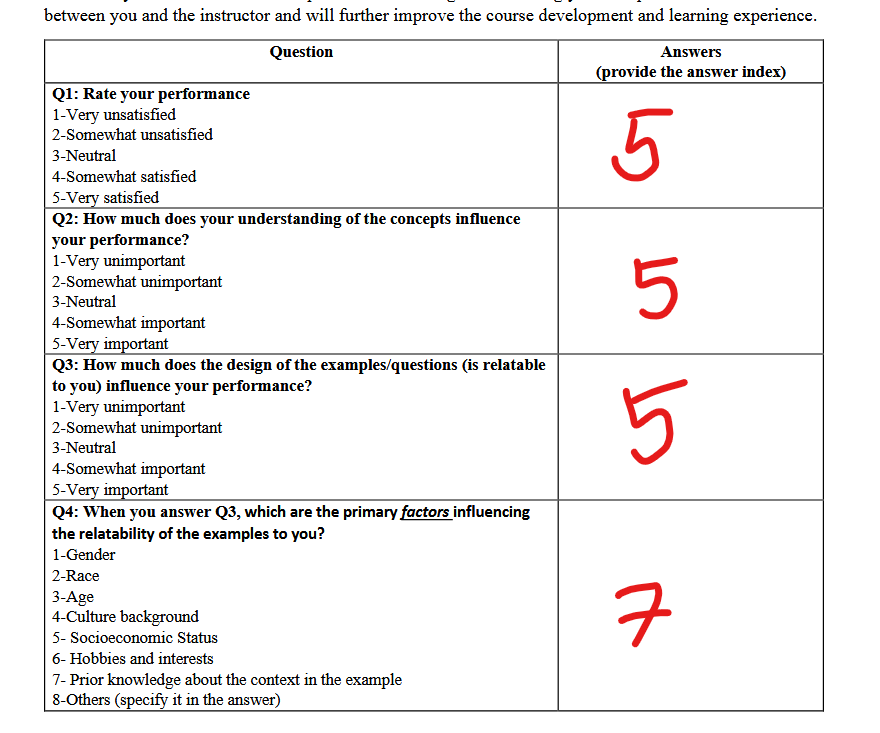